# 5-fold nested cross-validation over every classification head (RAD-DINO embeddings)

This notebook demonstrates how to evaluate **every classification head in
`sliceheads`** with unbiased, nested cross-validation: an outer 5-fold split
for performance estimation, and — independently, inside each outer training
fold — an inner 3-fold split for hyperparameter selection. Per-head
hyperparameter grids, the search strategy, and the dataset path all come
from `experiment_rad_dino.yaml` (a copy of `experiment.yaml` pointed at the
RAD-DINO embedding store), not from values hard-coded here.

**You will:** pool the full prepared embedding store, build reproducible
outer/inner `StratifiedKFold` splits, run `GridSearchCV`/`RandomizedSearchCV`
directly on each head (no wrapper — every head is a real sklearn estimator),
capture each scan's out-of-fold predicted probability, and report a pooled
ROC-AUC (with a stratified bootstrap CI) alongside the 5-fold mean ± std of
ROC-AUC, pooled AUPRC (class 0 positive), and pooled balanced accuracy.

This is a long-running notebook (every enabled head, every outer/inner fold,
its full hyperparameter grid) — see the "Running this notebook" note before
Step 4.

## Installation

Install the released package:

In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .

## Imports

Standard libs first, then the package's real public API. Every head below is
a plain sklearn estimator — `sklearn.model_selection` tools are used directly
on it, with no adapter class.

In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.metrics import compute_metrics
from sliceheads.heads import (
    MeanPoolClassifier,
    MaxPoolClassifier,
    GeMPoolClassifier,
    ABMILClassifier,
    GatedABMILClassifier,
    DSMILClassifier,
    TransformerMILClassifier,
    MultiRocketClassifier,
    InceptionTimeClassifier,
    ALSTMFCNClassifier,
)

## Configuration (ALL variables here)

Everything the notebook depends on — paths, seeds, and the nested-CV budget
— is set in this one cell.

In [3]:
# ---- Everything the notebook depends on is set here ----
EXPERIMENT_YAML_PATH = "experiment_rad_dino.yaml"   # per-head hyperparameter grids + run config (RAD-DINO store)

with open(EXPERIMENT_YAML_PATH) as fh:
    EXPERIMENT_CONFIG = yaml.safe_load(fh)

H5_PATH         = EXPERIMENT_CONFIG["data"]["h5_path"]              # relative, not absolute
RANDOM_SEED     = EXPERIMENT_CONFIG["training"]["random_seed"]       # <- change in experiment.yaml's training.random_seed, not here
SCORING         = EXPERIMENT_CONFIG["training"]["selection_metric"]  # inner-CV selection metric
SEARCH_STRATEGY = EXPERIMENT_CONFIG["search_strategy"]               # "grid" -> GridSearchCV

N_OUTER_FOLDS   = 5     # outer loop: unbiased performance estimate
N_INNER_FOLDS   = 3     # inner loop: hyperparameter selection only
N_HPO_ITER      = 25    # RandomizedSearchCV budget, only used if SEARCH_STRATEGY != "grid"

FOLDS_PATH           = "folds_mosmed_rad_dino.npz"             # serialized outer-fold indices
CHECKPOINT_PATH      = "nested_cv_checkpoint_rad_dino.json"    # per-fold aggregate metrics, written incrementally
OOF_CHECKPOINT_PATH  = "nested_cv_oof_checkpoint_rad_dino.json"  # per-scan OOF probabilities, written incrementally
OOF_PREDICTIONS_CSV  = "nested_cv_oof_predictions_rad_dino.csv"  # final long-format OOF predictions (head, scan_id, fold, true_label, prob_class_0/1)
SUMMARY_CSV          = "nested_cv_summary_rad_dino.csv"        # per-fold mean/std summary (supplementary)
RESULTS_TABLE_CSV    = "nested_cv_results_table_rad_dino.csv"  # pooled-OOF results table (primary deliverable)
PLOT_PATH            = "nested_cv_roc_auc_rad_dino.png"

N_BOOTSTRAPS    = 2000   # bootstrap resamples for each fold's own 95% ROC-AUC CI (via compute_metrics)
CI_LEVEL        = 0.95

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"device            : {DEVICE}")
print(f"H5_PATH           : {H5_PATH}  (from {EXPERIMENT_YAML_PATH})")
print(f"random_seed       : {RANDOM_SEED}")
print(f"selection_metric  : {SCORING}")
print(f"search_strategy   : {SEARCH_STRATEGY}")

device            : cuda
H5_PATH           : demo_output/prepared_embeddings_full_rad_dino.h5  (from experiment_rad_dino.yaml)
random_seed       : 42
selection_metric  : roc_auc
search_strategy   : grid


## Input format

`H5_PATH` is an HDF5 store with one group per sample, written by
`sliceheads.store.EmbedStore`:

```
prepared_embeddings_full_rad_dino.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   # e.g. [43, 768]
 │    └── attrs: label, split, patient_id
 └── ...
```

- **Source:** MosMedData-derived demo CT dataset, RAD-DINO slice embeddings
  (see `prepare_hdf5_embeddings_rad_dino.ipynb`).
- **Labels:** binary — 0 = CT0 (no CT signs of pneumonia), 1 = CT12 (any involvement).
- **Split:** the file carries a `train`/`val`/`test` attribute per sample, but
  nested cross-validation builds its *own* outer/inner splits from scratch —
  see `materials_and_methods.txt`, which notes that `sliceheads` deliberately
  does not implement nested CV internally and instead expects the caller to
  drive it. So this notebook pools **every** sample from the file, ignoring
  the stored split, and re-splits it below with `StratifiedKFold`.

## Step 1 — Validate and load the full dataset

`validate_h5` checks the schema; `EmbedStore.load_split` returns one
variable-length `[N_i, D]` array per sample. We call it once per stored split
and concatenate the three lists, since nested CV re-splits everything itself.

In [4]:
validate_h5(H5_PATH)
print("Validation passed ✓")

store = EmbedStore(H5_PATH)

embeddings_all, labels_all, ids_all = [], [], []
for split in ("train", "val", "test"):
    emb, y, ids = store.load_split(split)
    embeddings_all += emb
    labels_all += list(y)
    ids_all += ids

labels_all = np.array(labels_all, dtype=np.int64)
embedding_dim = embeddings_all[0].shape[1]

# X as a 1-D object array: sklearn's CV splitters index it like any other X,
# each element stays a ragged [N_i, embedding_dim] array — no padding here.
X_all = np.empty(len(embeddings_all), dtype=object)
for i, e in enumerate(embeddings_all):
    X_all[i] = e

print(f"total samples : {len(X_all)}")
print(f"embedding_dim : {embedding_dim}")
print(f"class balance : {dict(zip(*np.unique(labels_all, return_counts=True)))}")

Validation passed ✓


total samples : 1063
embedding_dim : 768
class balance : {np.int64(0): np.int64(254), np.int64(1): np.int64(809)}


## Step 2 — Per-head hyperparameter search spaces

Each head's search space now comes directly from `experiment.yaml` (the
`heads.<name>.hyperparameters` block, for every head with `enabled: true`)
— not from grids hard-coded in this notebook. To change what gets searched,
edit the YAML, not this cell. `experiment.yaml` also declares
`search_strategy: grid`; every enabled head's grid there is small enough
(a few configurations to a few dozen) that `GridSearchCV` searches it
exhaustively. `RandomizedSearchCV` with `n_iter=N_HPO_ITER` remains as a
fallback, used automatically if `search_strategy` is ever set to anything
other than `"grid"`. Fixed training-budget arguments not meant to be
searched (`max_epochs`, `patience`, `input_dim`, `device`, `random_seed`)
are still supplied at construction time.

In [5]:
HEAD_CLASSES = {
    "MeanPoolClassifier": MeanPoolClassifier,
    "MaxPoolClassifier": MaxPoolClassifier,
    "GeMPoolClassifier": GeMPoolClassifier,
    "MultiRocketClassifier": MultiRocketClassifier,
    "ABMILClassifier": ABMILClassifier,
    "GatedABMILClassifier": GatedABMILClassifier,
    "DSMILClassifier": DSMILClassifier,
    "TransformerMILClassifier": TransformerMILClassifier,
    "InceptionTimeClassifier": InceptionTimeClassifier,
    "ALSTMFCNClassifier": ALSTMFCNClassifier,
}

# Heads whose constructor takes input_dim/device (the PyTorch heads); the
# sklearn-pooling heads and the aeon head don't.
NEEDS_INPUT_DIM_DEVICE = {
    "ABMILClassifier", "GatedABMILClassifier", "DSMILClassifier",
    "TransformerMILClassifier", "InceptionTimeClassifier", "ALSTMFCNClassifier",
}

HEAD_SEARCH_SPACES = {}
for head_name, head_cfg in EXPERIMENT_CONFIG["heads"].items():
    if not head_cfg.get("enabled", False):
        continue
    cls = HEAD_CLASSES[head_name]
    kwargs = {"random_seed": RANDOM_SEED}
    if head_name in NEEDS_INPUT_DIM_DEVICE:
        kwargs.update(input_dim=embedding_dim, device=DEVICE)
    param_grid = {k: list(v) for k, v in head_cfg["hyperparameters"].items()}
    HEAD_SEARCH_SPACES[head_name] = (cls(**kwargs), param_grid)

for name, (_, grid) in HEAD_SEARCH_SPACES.items():
    n_combos = 1
    for values in grid.values():
        n_combos *= len(values)
    use_grid = SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER
    strategy = "GridSearchCV (exhaustive)" if use_grid else f"RandomizedSearchCV (n_iter={N_HPO_ITER})"
    print(f"{name:<26s} {n_combos:>4d} configs  ->  {strategy}")

MeanPoolClassifier            5 configs  ->  GridSearchCV (exhaustive)
MaxPoolClassifier             4 configs  ->  GridSearchCV (exhaustive)
GeMPoolClassifier             9 configs  ->  GridSearchCV (exhaustive)
ABMILClassifier              12 configs  ->  GridSearchCV (exhaustive)
GatedABMILClassifier          4 configs  ->  GridSearchCV (exhaustive)
DSMILClassifier               4 configs  ->  GridSearchCV (exhaustive)
TransformerMILClassifier      4 configs  ->  GridSearchCV (exhaustive)
InceptionTimeClassifier       4 configs  ->  GridSearchCV (exhaustive)
ALSTMFCNClassifier            4 configs  ->  GridSearchCV (exhaustive)
MultiRocketClassifier         3 configs  ->  GridSearchCV (exhaustive)


## Step 3 — Outer 5-fold split, serialized to disk

`StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)` gives
the outer performance-estimation folds. The indices are saved to
`folds_mosmed.npz` so the exact split can be reused or audited later without
re-running the notebook.

In [6]:
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_SEED)
outer_folds = list(outer_cv.split(X_all, labels_all))

folds_to_save = {}
for i, (train_idx, test_idx) in enumerate(outer_folds):
    folds_to_save[f"fold_{i}_train"] = train_idx
    folds_to_save[f"fold_{i}_test"] = test_idx
np.savez(FOLDS_PATH, **folds_to_save)

for i, (train_idx, test_idx) in enumerate(outer_folds):
    print(f"outer fold {i}: train={len(train_idx):4d}  test={len(test_idx):4d}")
print(f"\nfold indices written to {FOLDS_PATH}")

# Every scan must land in exactly one outer fold's test partition — this is
# what lets the pooled OOF vector (Step 6) be built by straight concatenation.
all_test_idx = np.concatenate([test_idx for _, test_idx in outer_folds])
assert len(all_test_idx) == len(X_all), "outer test folds do not cover the full cohort"
assert len(np.unique(all_test_idx)) == len(all_test_idx), "a scan appears in more than one outer test fold"
print("outer test folds: cover the full cohort, each scan exactly once ✓")

outer fold 0: train= 850  test= 213
outer fold 1: train= 850  test= 213
outer fold 2: train= 850  test= 213
outer fold 3: train= 851  test= 212
outer fold 4: train= 851  test= 212

fold indices written to folds_mosmed_rad_dino.npz
outer test folds: cover the full cohort, each scan exactly once ✓


## Step 4 — Nested cross-validation

For every outer fold: build a fresh inner `StratifiedKFold(3)`, then for
every head, run its `GridSearchCV` (or `RandomizedSearchCV`, per
`experiment.yaml`'s `search_strategy`) on the outer-training fold only,
refit the best configuration, and evaluate once on the held-out outer-test
fold with `compute_metrics` (which includes a 95% bootstrap ROC-AUC CI
computed *within that fold*). Results are appended to `CHECKPOINT_PATH`
after every single head/fold so progress survives an interruption.

**Per-scan OOF predictions.** This loop also records each held-out scan's
predicted probability, keyed by `scan_id`, into `oof_predictions` —
checkpointed to `OOF_CHECKPOINT_PATH` the same way, every head/fold.
Without this, there would be no way to pool predictions across the 5 outer
folds into one N=1063-length vector per head for Step 6's pooled ROC-AUC
and its bootstrap CI — aggregated per-fold metrics alone can't be
un-aggregated after the fact, which is why this notebook previously
couldn't produce that table.

**Running this notebook:** 5 outer folds x every enabled head x its full
hyperparameter grid is thousands of individual model fits. On this
machine's GPU it takes on the order of an hour; on CPU, considerably
longer — long enough that you should launch it as a background process
(e.g.
`nohup jupyter nbconvert --to notebook --execute --inplace nested_cross_validation_rad_dino.ipynb &`)
rather than run it interactively cell-by-cell.

In [7]:
fold_metrics = {name: [] for name in HEAD_SEARCH_SPACES}
best_params_log = {name: [] for name in HEAD_SEARCH_SPACES}
oof_predictions = {name: {} for name in HEAD_SEARCH_SPACES}  # head -> scan_id -> {fold, true_label, prob_class_0, prob_class_1}

start_all = time.time()

for fold_i, (train_idx, test_idx) in enumerate(outer_folds):
    X_train_outer, X_test_outer = X_all[train_idx], X_all[test_idx]
    y_train_outer, y_test_outer = labels_all[train_idx], labels_all[test_idx]
    ids_test_outer = [ids_all[i] for i in test_idx]
    inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_SEED + fold_i)

    for head_name, (estimator, param_grid) in HEAD_SEARCH_SPACES.items():
        t0 = time.time()

        n_combos = 1
        for values in param_grid.values():
            n_combos *= len(values)

        if SEARCH_STRATEGY == "grid" or n_combos <= N_HPO_ITER:
            search = GridSearchCV(
                estimator, param_grid, scoring=SCORING, cv=inner_cv,
                n_jobs=1, error_score=np.nan,
            )
            strategy = "grid"
        else:
            search = RandomizedSearchCV(
                estimator, param_grid, n_iter=N_HPO_ITER, scoring=SCORING, cv=inner_cv,
                random_state=RANDOM_SEED + fold_i, n_jobs=1, error_score=np.nan,
            )
            strategy = "random"

        search.fit(X_train_outer, y_train_outer)

        proba = search.best_estimator_.predict_proba(X_test_outer)
        m = compute_metrics(y_test_outer, proba, n_bootstraps=N_BOOTSTRAPS, ci=CI_LEVEL, random_seed=RANDOM_SEED)

        fold_metrics[head_name].append(m)
        best_params_log[head_name].append(search.best_params_)

        for sid, yt, p in zip(ids_test_outer, y_test_outer, proba):
            oof_predictions[head_name][sid] = {
                "fold": fold_i,
                "true_label": int(yt),
                "prob_class_0": float(p[0]),
                "prob_class_1": float(p[1]),
            }

        elapsed = time.time() - t0
        print(
            f"[fold {fold_i + 1}/{N_OUTER_FOLDS}] {head_name:<26s} "
            f"({strategy}, {n_combos} configs)  inner_best={search.best_score_:.3f}  "
            f"test_roc_auc={m['roc_auc']:.3f}  ({elapsed:.1f}s)",
            flush=True,
        )

        # Checkpoint after every head/fold so progress survives an interruption.
        with open(CHECKPOINT_PATH, "w") as fh:
            json.dump(fold_metrics, fh, indent=2)
        with open(OOF_CHECKPOINT_PATH, "w") as fh:
            json.dump(oof_predictions, fh, indent=2)

total_hours = (time.time() - start_all) / 3600
print(f"\nTotal nested CV runtime: {total_hours:.2f} hours")

[fold 1/5] MeanPoolClassifier         (grid, 5 configs)  inner_best=0.806  test_roc_auc=0.864  (5.3s)


[fold 1/5] MaxPoolClassifier          (grid, 4 configs)  inner_best=0.784  test_roc_auc=0.799  (2.9s)


[fold 1/5] GeMPoolClassifier          (grid, 9 configs)  inner_best=0.808  test_roc_auc=0.832  (9.6s)


[fold 1/5] ABMILClassifier            (grid, 12 configs)  inner_best=0.800  test_roc_auc=0.804  (11.3s)


[fold 1/5] GatedABMILClassifier       (grid, 4 configs)  inner_best=0.804  test_roc_auc=0.799  (5.5s)


...

[fold 5/5] TransformerMILClassifier   (grid, 4 configs)  inner_best=0.778  test_roc_auc=0.859  (12.0s)


[fold 5/5] InceptionTimeClassifier    (grid, 4 configs)  inner_best=0.820  test_roc_auc=0.830  (8.6s)


[fold 5/5] ALSTMFCNClassifier         (grid, 4 configs)  inner_best=0.818  test_roc_auc=0.851  (7.7s)


[fold 5/5] MultiRocketClassifier      (grid, 3 configs)  inner_best=0.675  test_roc_auc=0.648  (73.9s)



Total nested CV runtime: 0.19 hours


## Step 4b — Persist per-scan OOF predictions

Flatten `oof_predictions` into a long-format table (`scan_id`, `head`,
`fold`, `true_label`, `prob_class_0`, `prob_class_1`) and write it to
`OOF_PREDICTIONS_CSV`. The assertions below are the alignment guarantees
Step 6 depends on: every head must have exactly one OOF row per scan, and
that set of scans must be the full cohort — not just "the right count."

In [8]:
oof_rows = []
for head_name, preds in oof_predictions.items():
    for sid, p in preds.items():
        oof_rows.append({
            "scan_id": sid,
            "head": head_name,
            "fold": p["fold"],
            "true_label": p["true_label"],
            "prob_class_0": p["prob_class_0"],
            "prob_class_1": p["prob_class_1"],
        })
oof_df = pd.DataFrame(oof_rows)
oof_df.to_csv(OOF_PREDICTIONS_CSV, index=False)

# Every head must have exactly one row per scan, and that set of scans must
# be the full cohort — otherwise pooling/alignment in Step 6 is unsound.
for head_name in HEAD_SEARCH_SPACES:
    head_ids = oof_df.loc[oof_df["head"] == head_name, "scan_id"]
    assert len(head_ids) == len(ids_all), f"{head_name}: {len(head_ids)} OOF predictions, expected {len(ids_all)}"
    assert head_ids.is_unique, f"{head_name}: duplicate scan IDs in OOF predictions"
    assert set(head_ids) == set(ids_all), f"{head_name}: OOF scan IDs don't match the full cohort"

print(f"OOF predictions: {len(HEAD_SEARCH_SPACES)} heads x {len(ids_all)} scans, written to {OOF_PREDICTIONS_CSV}")

OOF predictions: 10 heads x 1063 scans, written to nested_cv_oof_predictions_rad_dino.csv


## Step 5 — Per-fold aggregate summary (supplementary)

For each head, the 5 outer-fold test metrics are summarized as mean ± std:
ROC-AUC, its 95% bootstrap CI (lower/upper bound, each reported as mean ± std
across folds — a *per-fold* CI, distinct from Step 6's pooled-OOF CI),
balanced accuracy, and per-class F1. Written to `SUMMARY_CSV` for the
per-class F1 detail that Step 6's pooled table doesn't carry; Step 6 is the
primary results table.

In [9]:
def summarize(folds):
    keys = (
        "roc_auc", "roc_auc_ci_lower", "roc_auc_ci_upper",
        "balanced_accuracy", "f1_class_0", "f1_class_1",
    )
    values = {k: np.array([f[k] for f in folds]) for k in keys}
    summary = {}
    for k in keys:
        summary[f"{k}_mean"] = values[k].mean()
        summary[f"{k}_std"] = values[k].std(ddof=1)
    return summary


rows = []
for head_name, folds in fold_metrics.items():
    s = summarize(folds)
    rows.append({
        "Head": head_name,
        "ROC-AUC": f"{s['roc_auc_mean']:.3f} ± {s['roc_auc_std']:.3f}",
        "95% CI": (
            f"[{s['roc_auc_ci_lower_mean']:.3f} ± {s['roc_auc_ci_lower_std']:.3f}, "
            f"{s['roc_auc_ci_upper_mean']:.3f} ± {s['roc_auc_ci_upper_std']:.3f}]"
        ),
        "Balanced Accuracy": f"{s['balanced_accuracy_mean']:.3f} ± {s['balanced_accuracy_std']:.3f}",
        "F1 (class 0)": f"{s['f1_class_0_mean']:.3f} ± {s['f1_class_0_std']:.3f}",
        "F1 (class 1)": f"{s['f1_class_1_mean']:.3f} ± {s['f1_class_1_std']:.3f}",
    })

df_summary = pd.DataFrame(rows).set_index("Head")
df_summary.to_csv(SUMMARY_CSV)
df_summary

,ROC-AUC,95% CI,Balanced Accuracy,F1 (class 0),F1 (class 1)
Head,,,,,
MeanPoolClassifier,0.839 ± 0.044,"[0.776 ± 0.054, 0.893 ± 0.038]",0.755 ± 0.055,0.604 ± 0.067,0.848 ± 0.024
MaxPoolClassifier,0.788 ± 0.023,"[0.713 ± 0.025, 0.857 ± 0.020]",0.715 ± 0.038,0.548 ± 0.043,0.815 ± 0.020
GeMPoolClassifier,0.817 ± 0.031,"[0.751 ± 0.034, 0.878 ± 0.028]",0.734 ± 0.041,0.572 ± 0.050,0.820 ± 0.025
ABMILClassifier,0.804 ± 0.028,"[0.733 ± 0.028, 0.871 ± 0.028]",0.734 ± 0.040,0.568 ± 0.045,0.808 ± 0.016
GatedABMILClassifier,0.790 ± 0.044,"[0.715 ± 0.047, 0.859 ± 0.043]",0.725 ± 0.044,0.555 ± 0.048,0.798 ± 0.014
DSMILClassifier,0.696 ± 0.027,"[0.609 ± 0.028, 0.778 ± 0.024]",0.639 ± 0.036,0.453 ± 0.048,0.771 ± 0.037
TransformerMILClassifier,0.805 ± 0.051,"[0.735 ± 0.058, 0.869 ± 0.044]",0.729 ± 0.048,0.561 ± 0.051,0.803 ± 0.028
InceptionTimeClassifier,0.839 ± 0.022,"[0.779 ± 0.026, 0.895 ± 0.019]",0.741 ± 0.036,0.582 ± 0.045,0.829 ± 0.038
ALSTMFCNClassifier,0.847 ± 0.030,"[0.787 ± 0.036, 0.901 ± 0.025]",0.736 ± 0.028,0.575 ± 0.041,0.803 ± 0.082


### Visualize ROC-AUC by head

A horizontal bar chart, sorted best-to-worst, with the 5-fold std as error
bars.

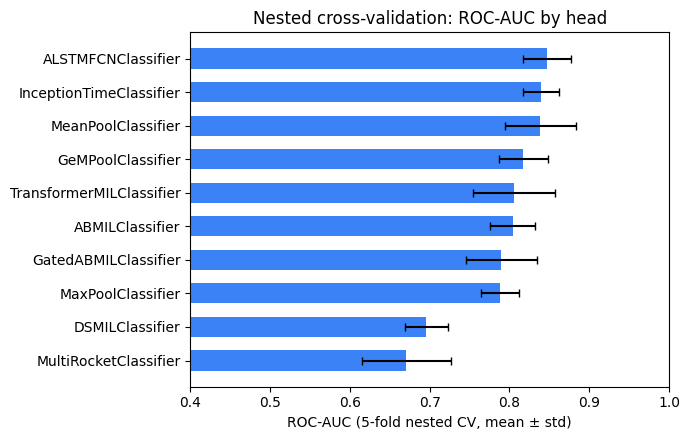

In [10]:
roc_auc_mean = {name: np.mean([f["roc_auc"] for f in folds]) for name, folds in fold_metrics.items()}
roc_auc_std = {name: np.std([f["roc_auc"] for f in folds], ddof=1) for name, folds in fold_metrics.items()}

order = sorted(roc_auc_mean, key=roc_auc_mean.get)
means = [roc_auc_mean[n] for n in order]
stds = [roc_auc_std[n] for n in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(order, means, xerr=stds, color="#3B82F6", edgecolor="none", height=0.6, capsize=3)
ax.set_xlabel("ROC-AUC (5-fold nested CV, mean ± std)")
ax.set_xlim(0.4, 1.0)
ax.set_title("Nested cross-validation: ROC-AUC by head")
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()

## Step 6 — Pooled-OOF results table (primary deliverable)

One row per head, **sorted by pooled ROC-AUC descending**, built from the
per-scan OOF predictions (Step 4b) rather than from aggregated per-fold
metrics:

- **`roc_auc_pooled` + 95% CI** — concatenate every head's 5 outer-fold OOF
  predictions into one length-N (N=1063) vector, aligned by `scan_id` (not
  positional order — enforced by the asserts below, on top of the Step 4b
  asserts). The point estimate is the ROC-AUC on that full pooled vector.
  The CI is the 2.5/97.5 percentile of `N_POOLED_BOOTSTRAPS` resamples,
  each stratified by class label (resampling *scans*, never slices) and
  reusing the *same* resampled indices across every head within a given
  iteration, so head-to-head comparisons stay paired. `POOLED_BOOTSTRAP_SEED`
  is recorded below.
- **`roc_auc_fold_mean` ± `std`** — plain mean/std of the 5 per-outer-fold
  ROC-AUC values already computed in Step 4 (`fold_metrics`), **not** from
  the bootstrap. This is a deliberately different quantity from the pooled
  CI above — fold-to-fold variability vs. overall pooled discrimination —
  and both belong in the table.
- **`auprc_class0`** — average precision with class 0 (CT-0, the 23.9%
  minority) as the positive class, on the pooled OOF vector. Uses
  `prob_class_0` scored against `true_label == 0`, not the default
  class-1-positive convention.
- **`balanced_accuracy`** — at the fixed 0.5 threshold (`prob_class_1 >=
  0.5`), matching what `head.predict()` does internally, on the pooled OOF
  vector.

In [11]:
N_POOLED_BOOTSTRAPS = 2000
POOLED_BOOTSTRAP_SEED = RANDOM_SEED
print(f"pooled-OOF bootstrap: n_resamples={N_POOLED_BOOTSTRAPS}  seed={POOLED_BOOTSTRAP_SEED}")

# scan_id -> true_label, fixed across all heads (every head shares the same outer folds)
y_pooled_by_id = oof_df.drop_duplicates("scan_id").set_index("scan_id")["true_label"].loc[ids_all]
y_pooled = y_pooled_by_id.to_numpy()

proba1_pool = {}  # head -> [N] prob_class_1, row-aligned to ids_all
proba0_pool = {}  # head -> [N] prob_class_0, row-aligned to ids_all
for head_name in HEAD_SEARCH_SPACES:
    head_df = oof_df[oof_df["head"] == head_name].set_index("scan_id").loc[ids_all]
    assert (head_df["true_label"].to_numpy() == y_pooled).all(), f"{head_name}: label mismatch after alignment"
    proba1_pool[head_name] = head_df["prob_class_1"].to_numpy()
    proba0_pool[head_name] = head_df["prob_class_0"].to_numpy()

# Stratified bootstrap: resample scans within each class, reusing the same
# resampled indices across every head within an iteration.
rng = np.random.default_rng(POOLED_BOOTSTRAP_SEED)
class0_idx = np.where(y_pooled == 0)[0]
class1_idx = np.where(y_pooled == 1)[0]
boot_indices = [
    np.concatenate([
        rng.choice(class0_idx, size=len(class0_idx), replace=True),
        rng.choice(class1_idx, size=len(class1_idx), replace=True),
    ])
    for _ in range(N_POOLED_BOOTSTRAPS)
]

rows = []
for head_name in HEAD_SEARCH_SPACES:
    y1, y0 = proba1_pool[head_name], proba0_pool[head_name]

    roc_auc_pooled = roc_auc_score(y_pooled, y1)
    boot_aucs = np.array([roc_auc_score(y_pooled[idx], y1[idx]) for idx in boot_indices])
    ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])

    fold_aucs = np.array([f["roc_auc"] for f in fold_metrics[head_name]])

    auprc_class0 = average_precision_score((y_pooled == 0).astype(int), y0)
    balanced_acc = balanced_accuracy_score(y_pooled, (y1 >= 0.5).astype(int))

    rows.append({
        "head": head_name,
        "roc_auc_pooled": roc_auc_pooled,
        "roc_auc_pooled_ci_low": ci_lo,
        "roc_auc_pooled_ci_high": ci_hi,
        "roc_auc_fold_mean": fold_aucs.mean(),
        "roc_auc_fold_std": fold_aucs.std(ddof=1),
        "auprc_class0": auprc_class0,
        "balanced_accuracy": balanced_acc,
    })

results_table = pd.DataFrame(rows).sort_values("roc_auc_pooled", ascending=False).reset_index(drop=True)
results_table.to_csv(RESULTS_TABLE_CSV, index=False)

results_table_display = pd.DataFrame({
    "head": results_table["head"],
    "roc_auc_pooled + 95% CI": [
        f"{a:.3f} [{lo:.3f}, {hi:.3f}]"
        for a, lo, hi in zip(
            results_table["roc_auc_pooled"],
            results_table["roc_auc_pooled_ci_low"],
            results_table["roc_auc_pooled_ci_high"],
        )
    ],
    "roc_auc_fold_mean ± std": [
        f"{m:.3f} ± {s:.3f}"
        for m, s in zip(results_table["roc_auc_fold_mean"], results_table["roc_auc_fold_std"])
    ],
    "auprc_class0": results_table["auprc_class0"].map("{:.3f}".format),
    "balanced_accuracy": results_table["balanced_accuracy"].map("{:.3f}".format),
}).set_index("head")

print(f"results table written to {RESULTS_TABLE_CSV}")
results_table_display

pooled-OOF bootstrap: n_resamples=2000  seed=42


results table written to nested_cv_results_table_rad_dino.csv


,roc_auc_pooled + 95% CI,roc_auc_fold_mean ± std,auprc_class0,balanced_accuracy
head,,,,
ALSTMFCNClassifier,"0.834 [0.805, 0.861]",0.847 ± 0.030,0.633,0.736
MeanPoolClassifier,"0.832 [0.805, 0.860]",0.839 ± 0.044,0.588,0.755
InceptionTimeClassifier,"0.821 [0.792, 0.850]",0.839 ± 0.022,0.559,0.740
GeMPoolClassifier,"0.817 [0.788, 0.847]",0.817 ± 0.031,0.580,0.734
TransformerMILClassifier,"0.805 [0.773, 0.836]",0.805 ± 0.051,0.572,0.729
ABMILClassifier,"0.801 [0.770, 0.832]",0.804 ± 0.028,0.566,0.734
GatedABMILClassifier,"0.791 [0.760, 0.823]",0.790 ± 0.044,0.548,0.724
MaxPoolClassifier,"0.785 [0.752, 0.816]",0.788 ± 0.023,0.529,0.715
DSMILClassifier,"0.680 [0.641, 0.719]",0.696 ± 0.027,0.411,0.639


## Results

**Primary table:** Step 6's pooled-OOF results table — `head`,
`roc_auc_pooled` + 95% CI, `roc_auc_fold_mean` ± std, `auprc_class0`,
`balanced_accuracy` — sorted by pooled ROC-AUC descending, written to
`RESULTS_TABLE_CSV`. The per-scan OOF predictions it's built from live in
`OOF_PREDICTIONS_CSV`, keyed by `scan_id`. `nested_cv_summary.csv` (Step 5)
and `nested_cv_checkpoint.json` (raw per-fold metrics) remain as
supplementary per-fold detail so nothing needs to be reproduced by
re-running the whole search.

## Troubleshooting

- **FileNotFoundError on `H5_PATH`:** run `prepare_hdf5_embeddings_rad_dino.ipynb`
  first, or point `experiment_rad_dino.yaml`'s `data.h5_path` at your own
  embedding store.
- **`validate_h5` raises "No samples with split='train'/'test'"**: the store
  needs at least one sample in each of the `train` and `test` splits (even
  though this notebook pools all splits together afterward).
- **CUDA not available:** `DEVICE` falls back to `"cpu"` automatically — the
  neural heads just train much more slowly; expect the run to take
  considerably longer than the GPU estimate in Step 4.
- **`MultiRocketClassifier` ImportError:** this head needs `aeon`
  (`pip install aeon`).
- **Kernel/terminal closed mid-run:** re-running the notebook from Step 4
  restarts the search from scratch; `CHECKPOINT_PATH` and
  `OOF_CHECKPOINT_PATH` hold whatever per-fold metrics and per-scan OOF
  predictions were written before the interruption if you want to inspect
  partial results instead of waiting for a full rerun.
- **`ValueError` from a search's inner CV (too few samples per class):** a
  head's internal early-stopping validation split (or the inner 3-fold
  split itself) needs at least a couple of samples per class in every fold;
  this dataset's class balance is large enough that it shouldn't occur, but
  a much smaller custom dataset could trigger it.
- **Changing what gets searched:** edit `experiment_rad_dino.yaml` — `heads.<name>.enabled`
  to add/drop a head, `heads.<name>.hyperparameters` to change its grid.
  Nothing in this notebook needs to change to pick that up.

## Conclusion

In this notebook we pooled the full prepared embedding store, built
reproducible 5-fold outer / 3-fold inner `StratifiedKFold` splits, and ran
`GridSearchCV`/`RandomizedSearchCV` directly on every enabled `sliceheads`
classification head — no wrapper, since every head is a real sklearn
estimator — using the per-head hyperparameter grids and search strategy
defined in `experiment.yaml`. Beyond the usual per-fold aggregate metrics,
we captured each scan's out-of-fold predicted probability and pooled them
into one N=1063-length vector per head, aligned by scan ID, to report a
pooled ROC-AUC with a stratified bootstrap CI alongside the per-fold
mean ± std, pooled AUPRC (class 0 positive), and pooled balanced accuracy.
The same workflow applies to a different dataset or head subset: point
`experiment_rad_dino.yaml`'s `data.h5_path` at another store, or toggle
heads' `enabled` flags.